In [7]:
!pip install tiktoken
token = ""

In [1]:
from transformers import AutoTokenizer
import numpy as np
import matplotlib.pyplot as plt

# Define test sentences in Hindi, English, and Tamil

test_sentences = {
    "English": [
        "The quick brown fox jumps over the lazy dog.",  # Simple sentence
        "Artificial intelligence is transforming the world rapidly.",  # Tech-related
        "A journey of a thousand miles begins with a single step.",  # Proverb
        "She danced gracefully under the shimmering moonlight.",  # Descriptive
        "What is the meaning of life in this vast universe?",  # Philosophical
    ],
    "Hindi": [
        "तेज़ भूरी लोमड़ी आलसी कुत्ते के ऊपर कूदती है।",
        "कृत्रिम बुद्धिमत्ता दुनिया को तेजी से बदल रही है।",
        "हजारों मील की यात्रा एक कदम से शुरू होती है।",
        "वह चमकते चांदनी के नीचे सुंदरता से नृत्य करती थी।",
        "इस विशाल ब्रह्मांड में जीवन का अर्थ क्या है?",
    ],
    "Tamil": [
        "விரைவான பழுப்பு நரி சோம்பேறி நாய் மீது குதிக்கிறது.",
        "செயற்கை நுண்ணறிவு உலகத்தை வேகமாக மாற்றுகிறது.",
        "ஆயிரம் மைல் பயணம் ஒரு அடியில் தொடங்குகிறது.",
        "அவள் பிரகாசிக்கும் நிலவொளியின் கீழ் அழகாக நடனமாடினாள்.",
        "இந்த பிரபஞ்சத்தில் வாழ்க்கையின் பொருள் என்ன?",
    ],
    "Bengali": [
        "চটপটে বাদামী শিয়ালটি অলস কুকুরটির ওপর লাফ দিল।",
        "কৃত্রিম বুদ্ধিমত্তা দ্রুত বিশ্বকে পরিবর্তন করছে।",
        "হাজার মাইলের যাত্রা একটি ছোট পদক্ষেপ দিয়ে শুরু হয়।",
        "সে দীপ্তিময় জোছনার নিচে সুন্দরভাবে নৃত্য করেছিল।",
        "এই বিশাল মহাবিশ্বে জীবনের মানে কী?",
    ],
    "Gujarati": [
        "ઝડપી ભૂરી લોમડી આળસુ કૂતરાં પર કૂદી પડે છે.",
        "કૃત્રિમ બુદ્ધિમત્તા વિશ્વને ઝડપી ગતિએ બદલી રહી છે.",
        "હજારો માઇલની યાત્રા એક પગલાથી શરૂ થાય છે.",
        "તે તેજસ્વી ચાંદની નીચે કળાત્મક રીતે નાચી હતી.",
        "આ વિશાળ બ્રહ્માંડમાં જીવનનો અર્થ શું છે?",
    ],
    "Kannada": [
        "ಚುರುಕಾದ ಬೂದು ನರಿ ಆಲಸ್ಯಕರೆ ನಾಯಿ ಮೇಲೆ ಹಾರುತ್ತದೆ.",
        "ಕೃತಕ ಬುದ್ಧಿಮತ್ತೆ ಪ್ರಪಂಚವನ್ನು ವೇಗವಾಗಿ ಬದಲಿಸುತ್ತಿದೆ.",
        "ಸಾವಿರ ಮೈಲಿನ ಪ್ರಯಾಣ ಒಂದು ಹೆಜ್ಜೆಯಿಂದ ಆರಂಭವಾಗುತ್ತದೆ.",
        "ಅವಳು ತೇಜಸ್ವಿ ಚಂದಿರ ಬೆಳಕಿನ ಕೆಳಗೆ ಅಂದವಾಗಿ ನೃತ್ಯ ಮಾಡಿದರು.",
        "ಈ ವಿಶಾಲ ಬ್ರಹ್ಮಾಂಡದಲ್ಲಿ ಬದುಕಿನ ಅರ್ಥವೇನು?",
    ],
    "Malayalam": [
        "വേഗമുള്ള തവിട്ട് നരി ആൽസ്യനായ നായയുടെ മേൽ ചാടുന്നു.",
        "കൃത്രിമ ബുദ്ധിമുട്ട ലോകത്തെ വേഗത്തിൽ മാറ്റുന്നു.",
        "ആയിരം മൈൽ യാത്ര ഒരു ചുവടുമായി ആരംഭിക്കുന്നു.",
        "അവൾ തിളങ്ങുന്ന ചന്ദ്രികയുടെ കീഴിൽ മനോഹരമായി നൃത്തം ചെയ്തു.",
        "ഈ വിശാലമായ ബ്രഹ്മാണ്ഡത്തിൽ ജീവിതത്തിന്റെ അർഥം എന്താണ്?",
    ],
    "Marathi": [
        "चपळ तपकिरी कोल्हा आळशी कुत्र्यावर उडी मारतो.",
        "कृत्रिम बुद्धिमत्ता जग वेगाने बदलत आहे.",
        "हजारो मैलांचा प्रवास एका पावलाने सुरू होतो.",
        "ती तेजस्वी चंद्रप्रकाशात सुंदरतेने नाचत होती.",
        "या विशाल ब्रह्मांडात जीवनाचा अर्थ काय?",
    ],
    "Oriya": [
        "ତୀବ୍ର ବାଦାମି ଶିଆଳଟି ଅଳସ କୁକୁର ଉପରେ ଲାଫିଲା।",
        "କୃତ୍ରିମ ବୁଦ୍ଧିମତା ବିଶ୍ୱକୁ ଦ୍ରୁତ ଗତିରେ ପରିବର୍ତ୍ତନ କରୁଛି।",
        "ହଜାର ମିଲର ଯାତ୍ରା ଗୋଟିଏ ପଦକ୍ଷେପରୁ ଆରମ୍ଭ ହୁଏ।",
        "ସେ ଜ୍ଵଳନ୍ତ ଚନ୍ଦ୍ରାଲୋକ ତଳେ ସୁନ୍ଦରଭାବେ ନୃତ୍ୟ କରୁଥିଲା।",
        "ଏହି ବିଶାଳ ବ୍ରହ୍ମାଣ୍ଡରେ ଜୀବନର ଅର୍ଥ କଣ?",
    ],
    "Punjabi": [
        "ਤਿੱਖੀ ਭੂਰੀ ਲੋਮੜੀ ਸੁਸਤੀ ਕੁੱਤੇ ਉੱਤੇ ਛਾਲ ਮਾਰਦੀ ਹੈ।",
        "ਕ੍ਰਿਤ੍ਰਿਮ ਬੁੱਧੀਮਤਾ ਦੁਨੀਆ ਨੂੰ ਤੇਜ਼ੀ ਨਾਲ ਬਦਲ ਰਹੀ ਹੈ।",
        "ਹਜ਼ਾਰ ਮੀਲ ਦੀ ਯਾਤਰਾ ਇਕ ਕਦਮ ਨਾਲ ਸ਼ੁਰੂ ਹੁੰਦੀ ਹੈ।",
        "ਉਹ ਚਮਕਦਾਰੀ ਚੰਨਣ ਹੇਠ ਸੁੰਦਰਤਾ ਨਾਲ ਨੱਚੀ।",
        "ਇਸ ਵਿਸ਼ਾਲ ਬ੍ਰਹਿਮੰਡ ਵਿੱਚ ਜੀਵਨ ਦਾ ਅਰਥ ਕੀ ਹੈ?",
    ],
    "Telugu": [
        "వేగంగా నలుపు నక్క మోసపూరిత కుక్కపై ఎగిరింది.",
        "కృత్రిమ మేధస్సు ప్రపంచాన్ని వేగంగా మారుస్తోంది.",
        "వెయ్యి మైళ్ల ప్రయాణం ఒక అడుగుతో మొదలవుతుంది.",
        "ఆమె మెరిసే చందమామ కాంతిలో అందంగా నాట్యం చేసింది.",
        "ఈ విస్తారమైన బ్రహ్మాండంలో జీవితం అర్థం ఏమిటి?",
    ],
    "Urdu": [
        "چست بھورا لومڑی سست کتے پر چھلانگ لگاتی ہے۔",  # Simple sentence
        "مصنوعی ذہانت دنیا کو تیزی سے بدل رہی ہے۔",  # Tech-related
        "ہزار میل کا سفر ایک قدم سے شروع ہوتا ہے۔",  # Proverb
        "وہ چمکتی چاندنی میں خوبصورتی سے رقص کر رہی تھی۔",  # Descriptive
        "اس وسیع کائنات میں زندگی کا مطلب کیا ہے؟",  # Philosophical
    ]
}

In [3]:
from transformers import AutoTokenizer
import tiktoken
import numpy as np
import matplotlib.pyplot as plt
import tqdm

In [8]:
model_configs = {
    "Phi-4": "microsoft/phi-4",
    "Phi-4 Mini": "microsoft/Phi-4-mini-instruct",  
    "Gemma 3 1B": "google/gemma-3-1b-it",
    "Gemma 3 4B": "google/gemma-3-4b-it",
    "Gemma 3 12B": "google/gemma-3-12b-it",
    "Gemma 3 27B": "google/gemma-3-27b-it",
    "Sarvam 1 2B": "sarvamai/sarvam-1",
    "Nemotron 4 Min-Hindi 4B": "nvidia/Nemotron-4-Mini-Hindi-4B-Instruct",
    "Aya expanse 8B": "CohereForAI/aya-expanse-8b",
    "Gemini": "describeai/gemini",
    "GPT-4o": "gpt-4o"
}

In [11]:
def calculate_fertility(text, tokens):
    """
    Calculates token fertility: number of tokens per character.
    """
    char_count = len(text)
    if char_count == 0:
        return 0.0
    return len(tokens) / char_count


def calculate_word_fertility(text, tokens):
    """
    Calculates word-level token fertility: number of tokens per word.
    """
    word_count = len(text.split())
    if word_count == 0:
        return 0.0
    return len(tokens) / word_count

In [12]:
def evaluate_tokenizer(model_name, model_id, sentences):
    try:
        if model_id == "gpt-4o":
            tokenizer = tiktoken.encoding_for_model("gpt-4o")
            is_tiktoken = True
        else:
            # Use Hugging Face tokenizer
            tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True, token=token)
            is_tiktoken = False
            

        fertility_scores = {}
        word_fertility_scores = {}

        for lang, texts in sentences.items():
            scores = []
            word_scores = []

            for text in texts:
                if is_tiktoken:
                    encoded = tokenizer.encode(text)
                else:
                    encoded = tokenizer.encode(text, add_special_tokens=False)

                token_count = len(encoded)
                char_count = len(text)
                word_count = len(text.split())

                score = calculate_fertility(text, encoded)
                word_score = calculate_word_fertility(text, encoded)

                scores.append(score)
                word_scores.append(word_score)

                print(f"\nModel: {model_name}, Language: {lang}")
                print(f"Text: {text}")
                print(f"Token Count: {token_count}, Char Count: {char_count}, Word Count: {word_count}")
                print(f"Fertility Score: {score:.4f} tokens/char")
                print(f"Word-Level Fertility Score: {word_score:.4f} tokens/word")

            fertility_scores[lang] = np.mean(scores)
            word_fertility_scores[lang] = np.mean(word_scores)

        return {"tokens_per_char": fertility_scores, "tokens_per_word": word_fertility_scores}

    except Exception as e:
        print(f"❌ Error loading tokenizer for {model_name}: {str(e)}")
        return None

In [13]:
results = {}
print("\n Starting tokenizer evaluation...\n")
for model_name, model_id in (model_configs.items()):
    print(f"\nEvaluating {model_name}...")
    scores = evaluate_tokenizer(model_name, model_id, test_sentences)
    if scores:
        results[model_name] = scores


 Starting tokenizer evaluation...


Evaluating Phi-4...

Model: Phi-4, Language: English
Text: The quick brown fox jumps over the lazy dog.
Token Count: 10, Char Count: 44, Word Count: 9
Fertility Score: 0.2273 tokens/char
Word-Level Fertility Score: 1.1111 tokens/word

Model: Phi-4, Language: English
Text: Artificial intelligence is transforming the world rapidly.
Token Count: 9, Char Count: 58, Word Count: 7
Fertility Score: 0.1552 tokens/char
Word-Level Fertility Score: 1.2857 tokens/word

Model: Phi-4, Language: English
Text: A journey of a thousand miles begins with a single step.
Token Count: 12, Char Count: 56, Word Count: 11
Fertility Score: 0.2143 tokens/char
Word-Level Fertility Score: 1.0909 tokens/word

Model: Phi-4, Language: English
Text: She danced gracefully under the shimmering moonlight.
Token Count: 10, Char Count: 53, Word Count: 7
Fertility Score: 0.1887 tokens/char
Word-Level Fertility Score: 1.4286 tokens/word

Model: Phi-4, Language: English
Text: What is the m

In [14]:
def plot_fertility_bar_graph(results, language, metric_type="tokens_per_char"):
    models = list(results.keys())
    scores = [results[model][metric_type][language] for model in models]
    colors = plt.cm.tab20(np.linspace(0, 1, len(models)))

    plt.figure(figsize=(14, 6))
    bars = plt.bar(models, scores, color=colors)
    plt.title(f'{metric_type.replace("_", " ").title()} for {language}', fontsize=14)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel(f'{metric_type.replace("_", " ").title()}', fontsize=12)
    plt.ylim(0, max(scores) * 1.2)
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(scores):
        plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

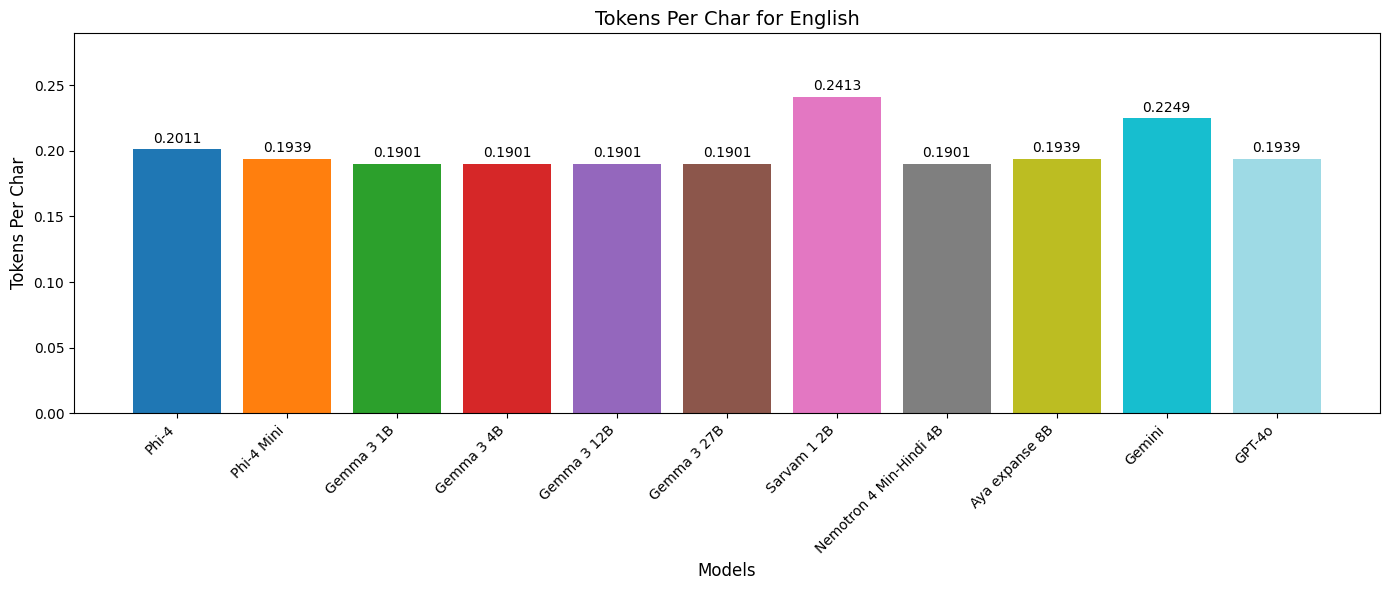

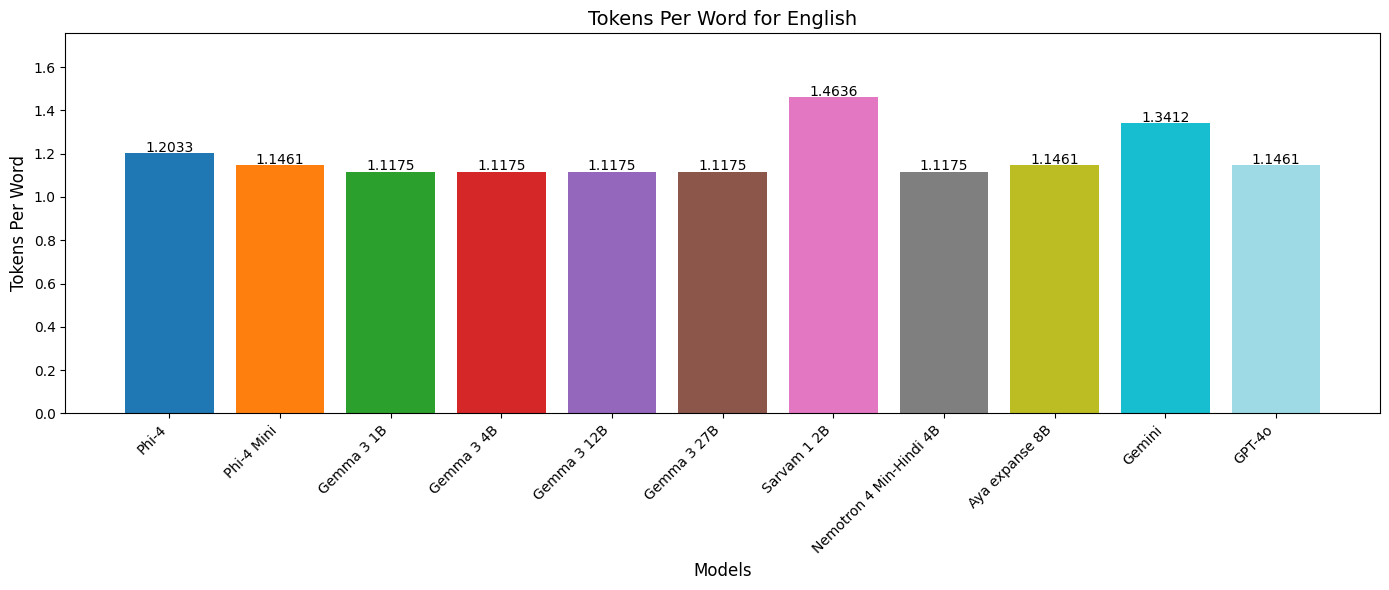

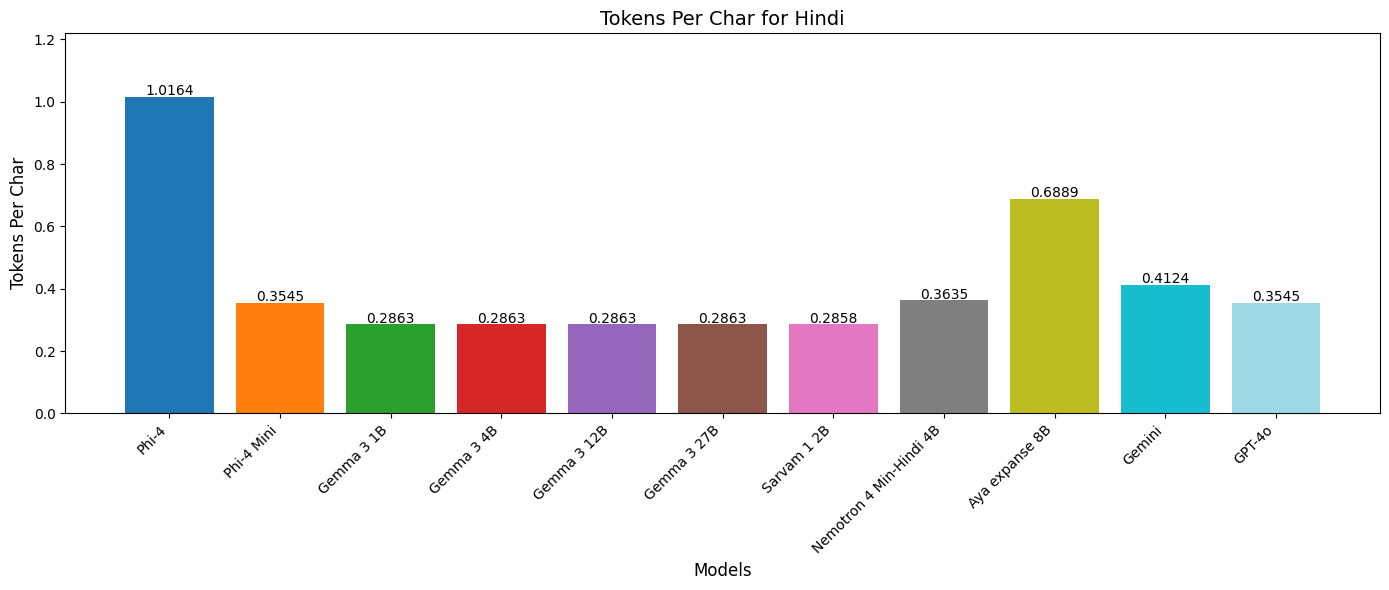

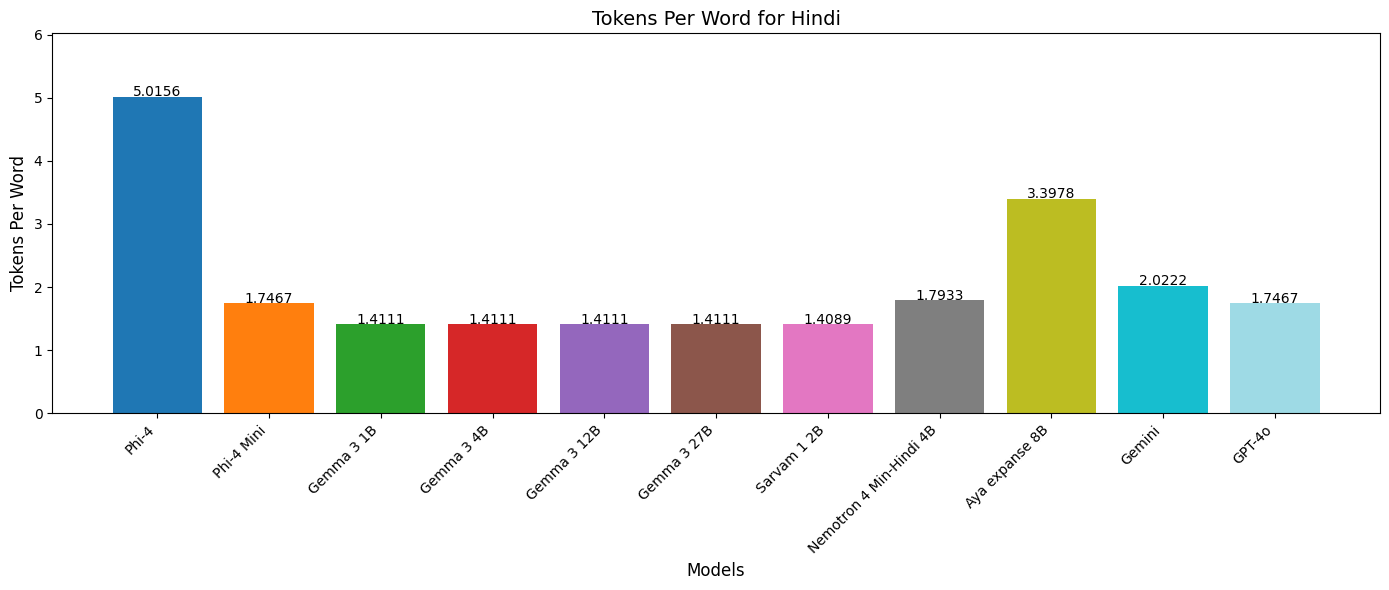

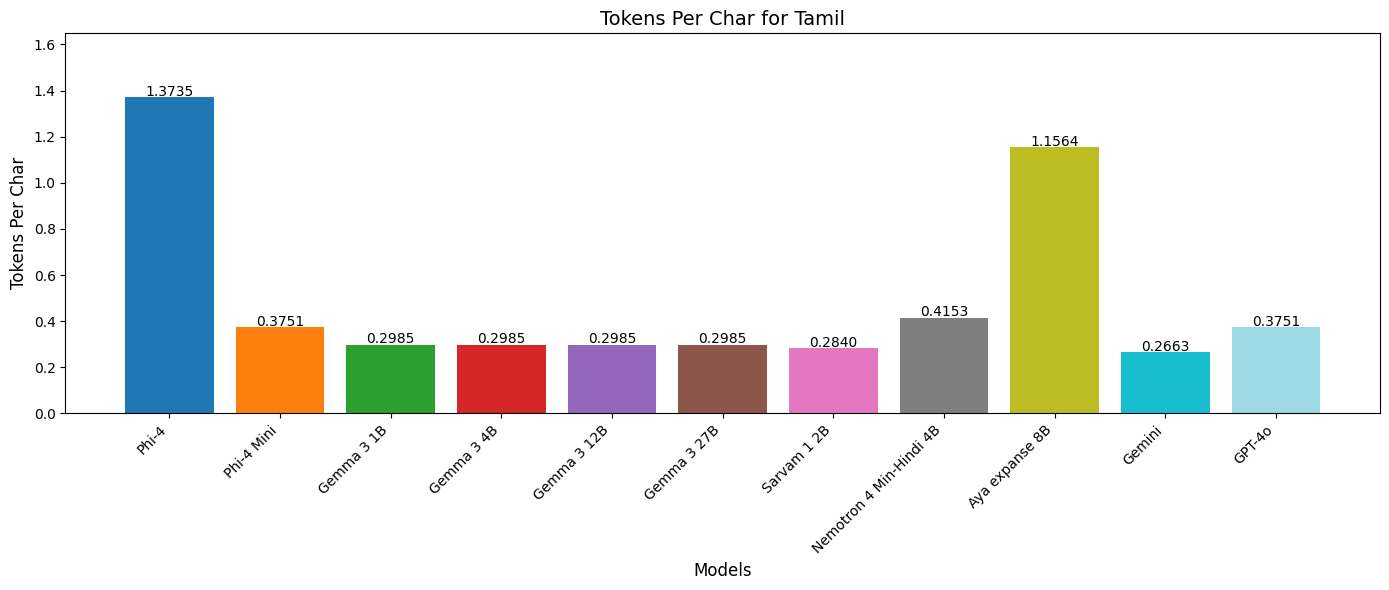

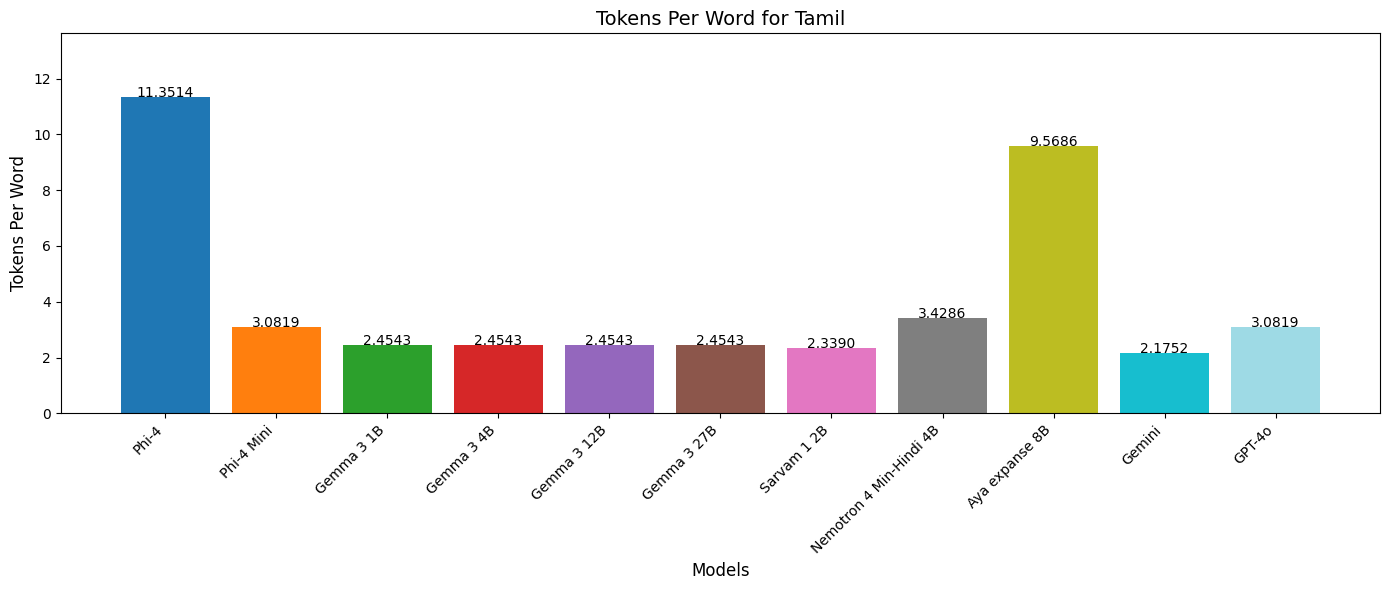

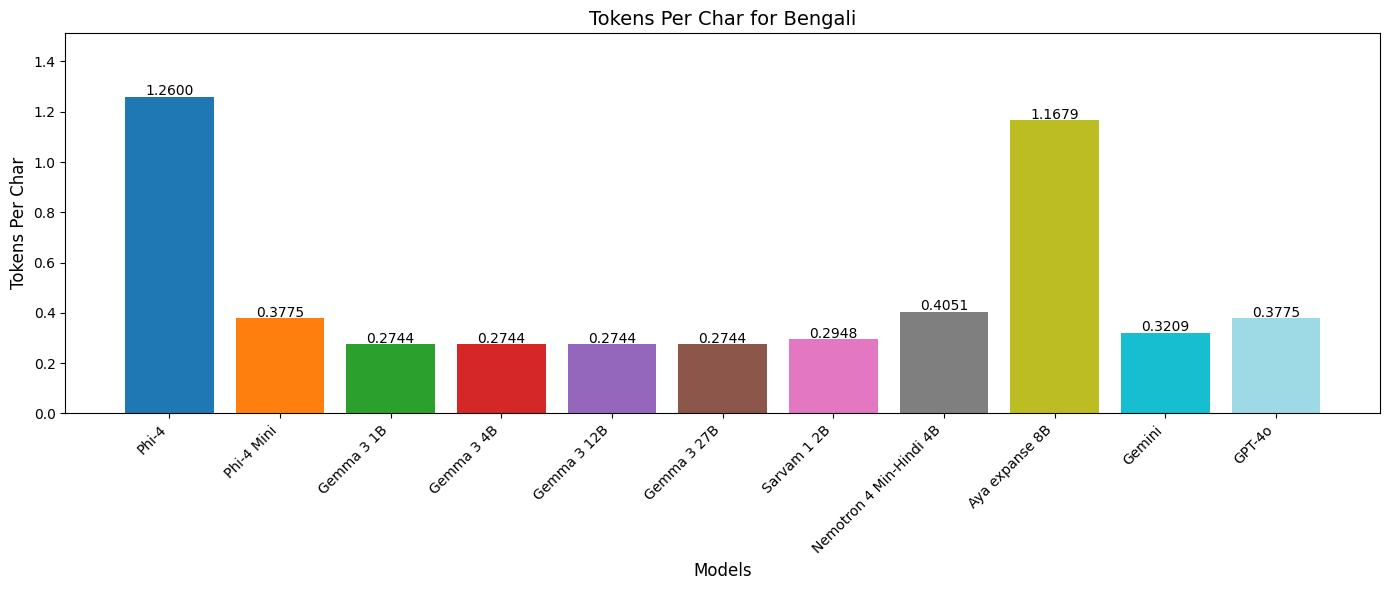

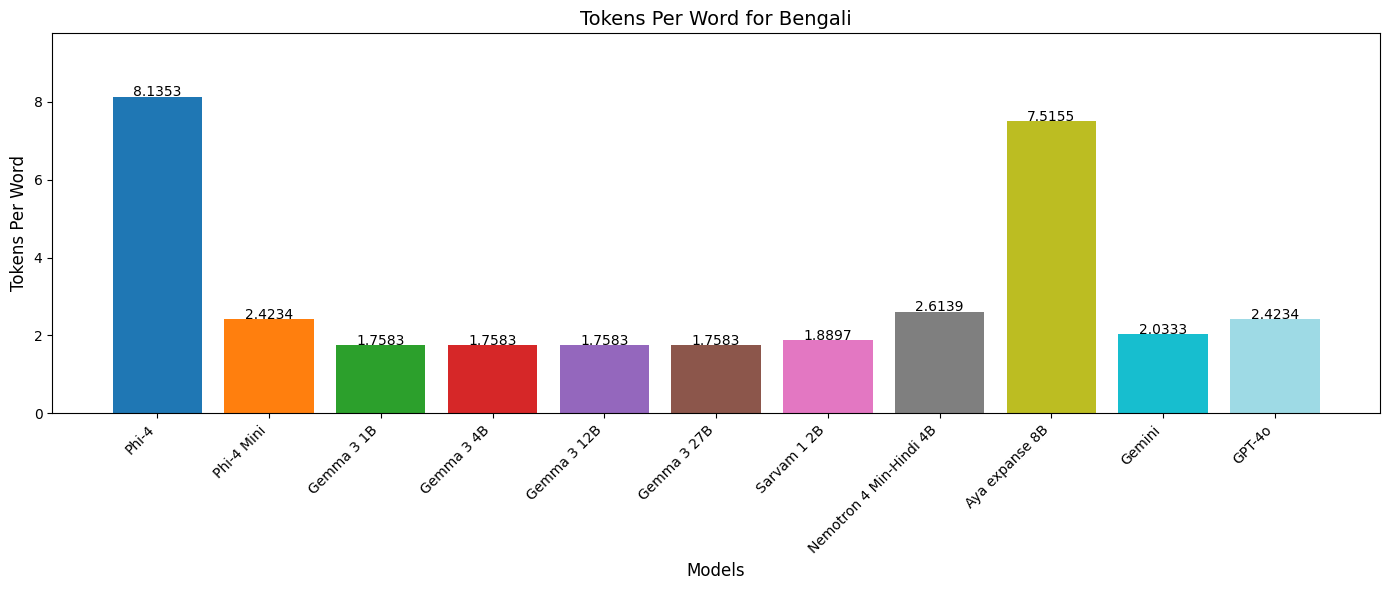

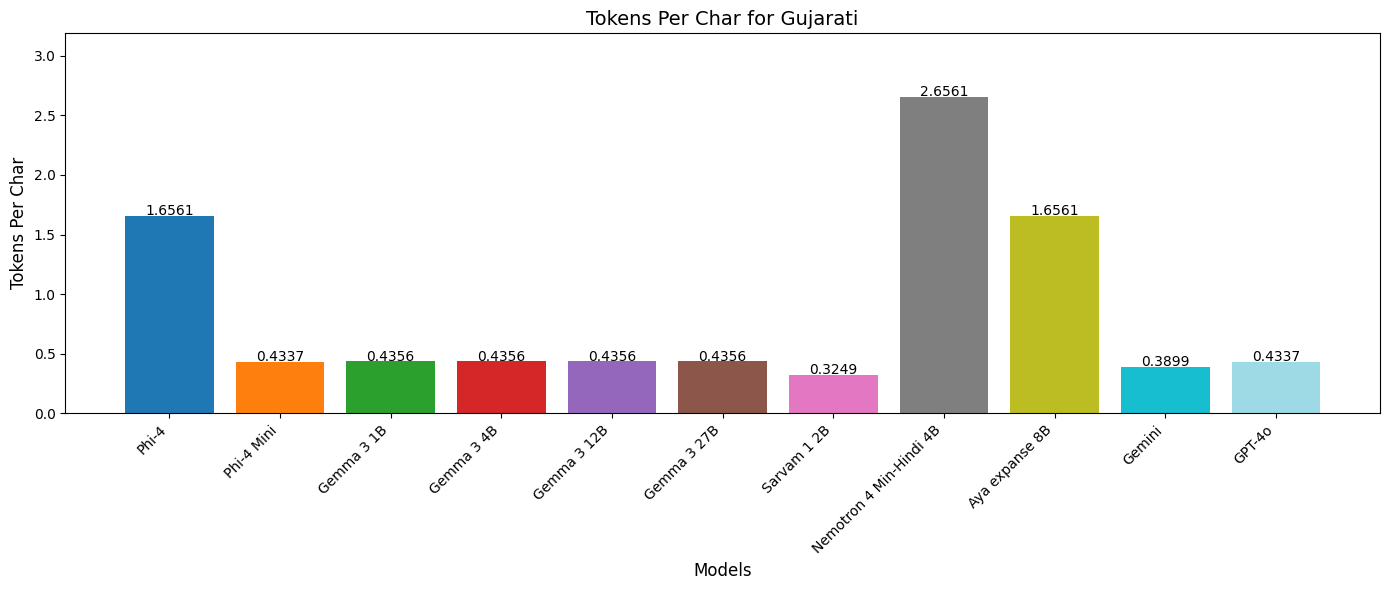

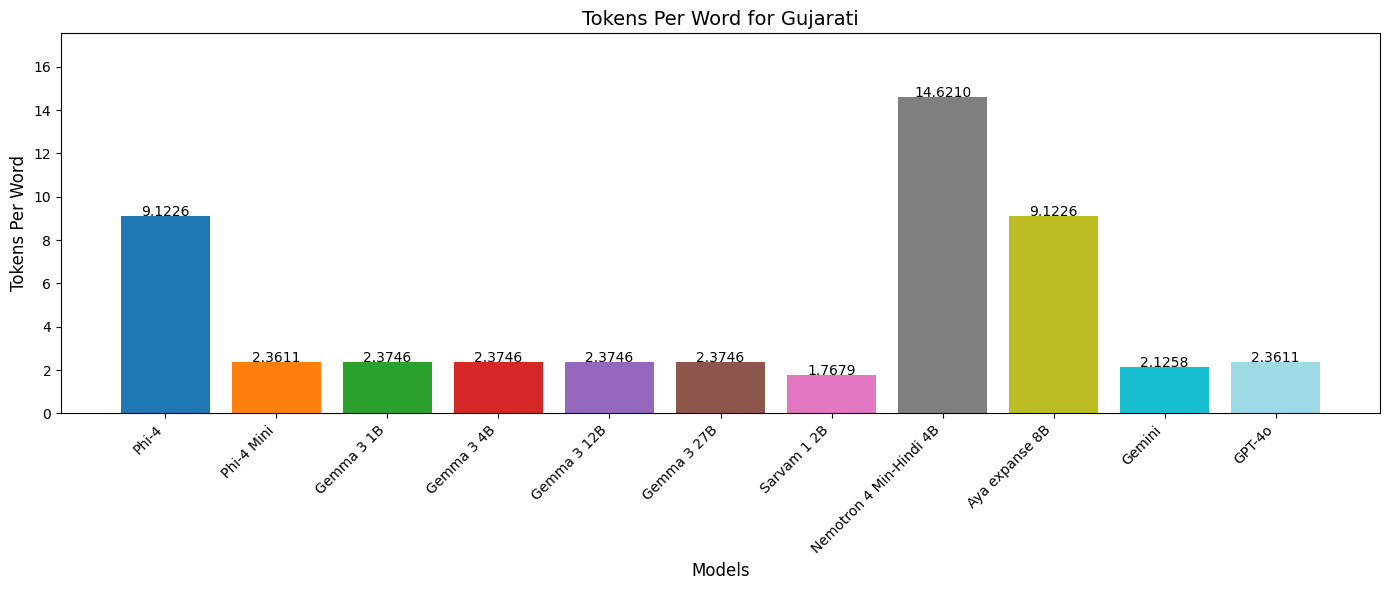

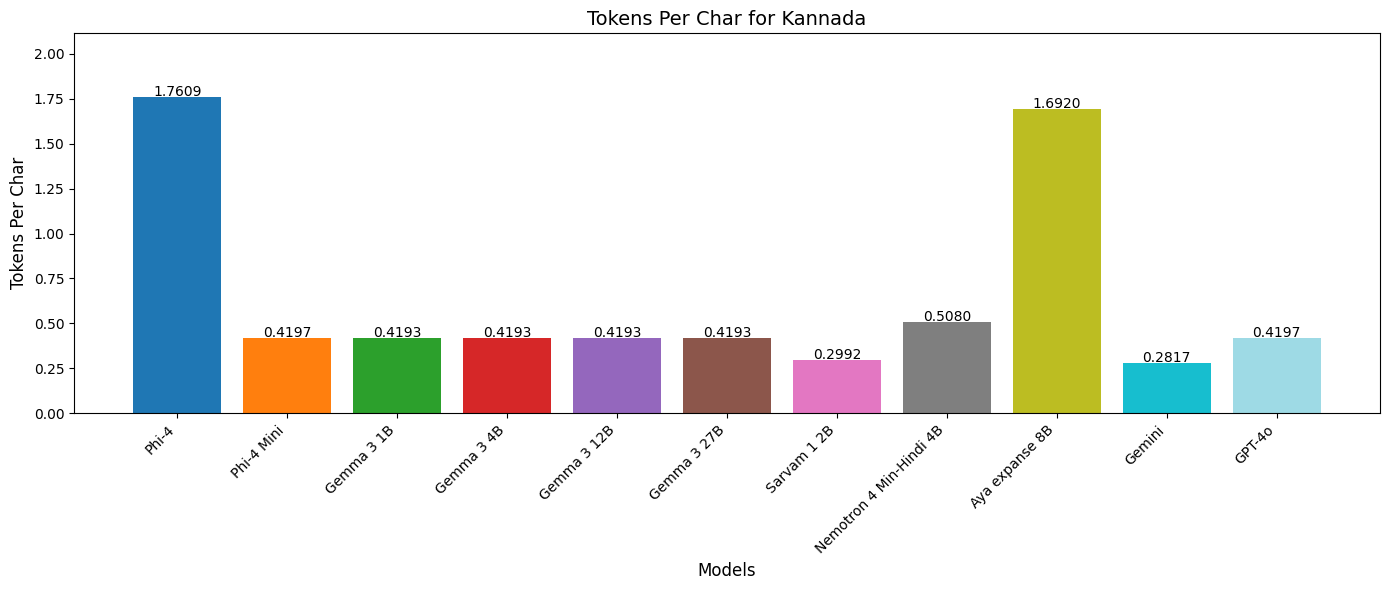

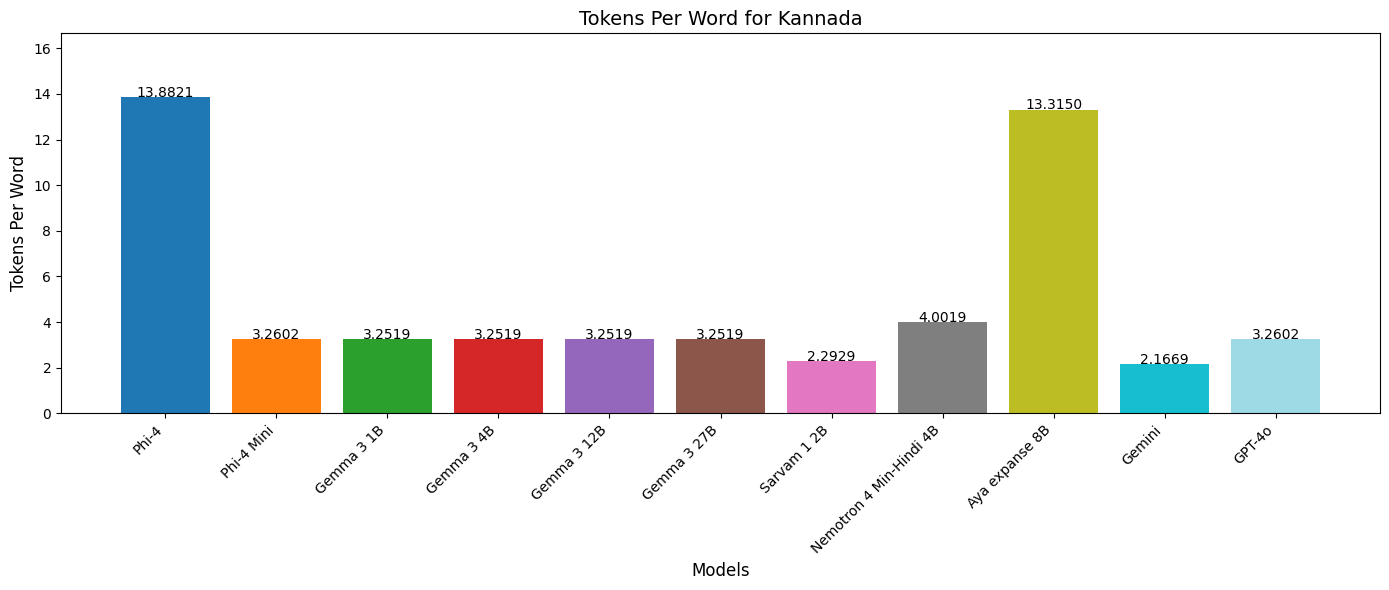

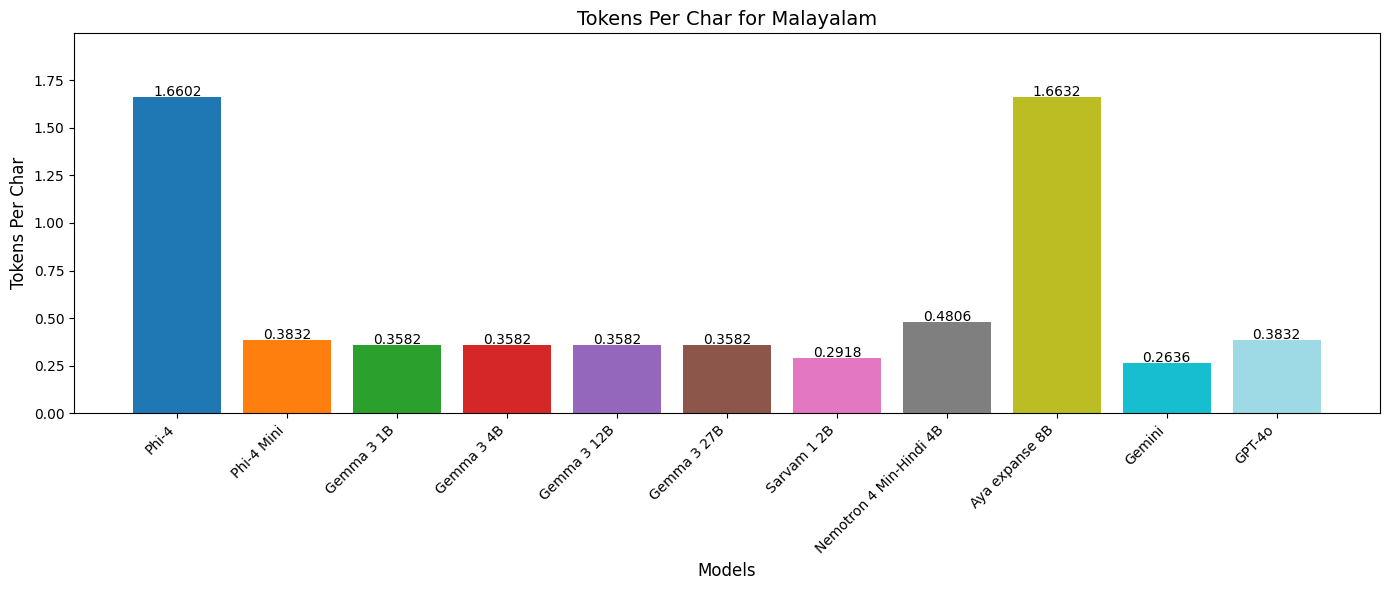

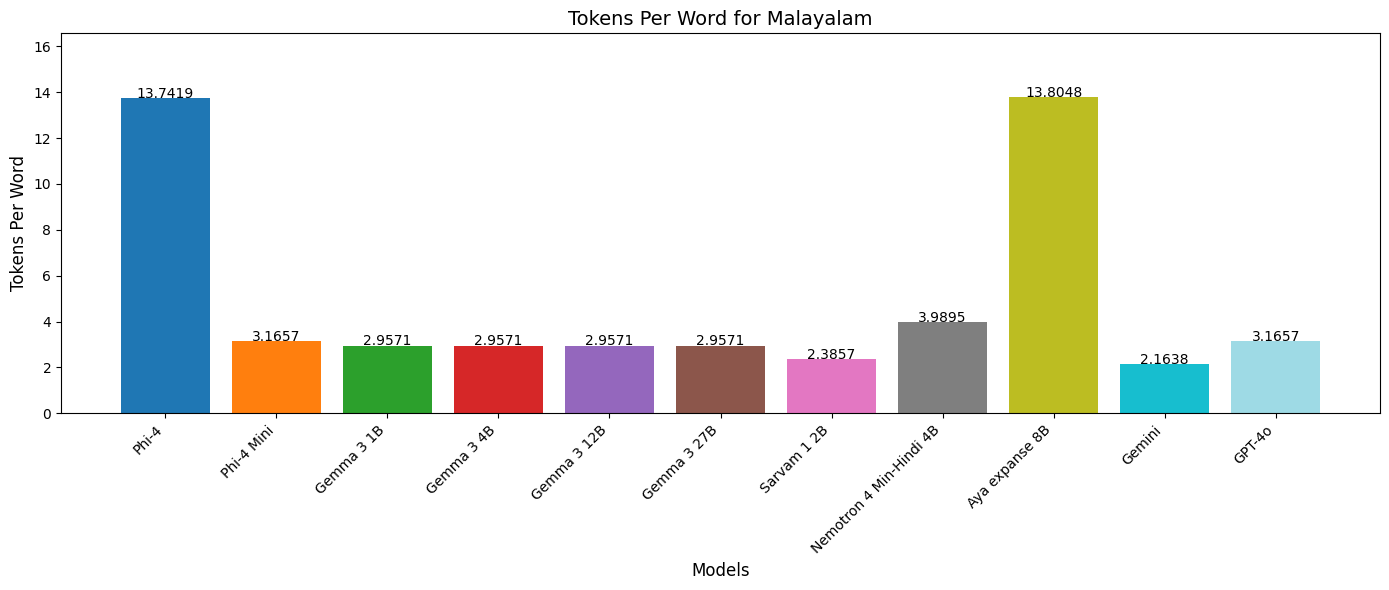

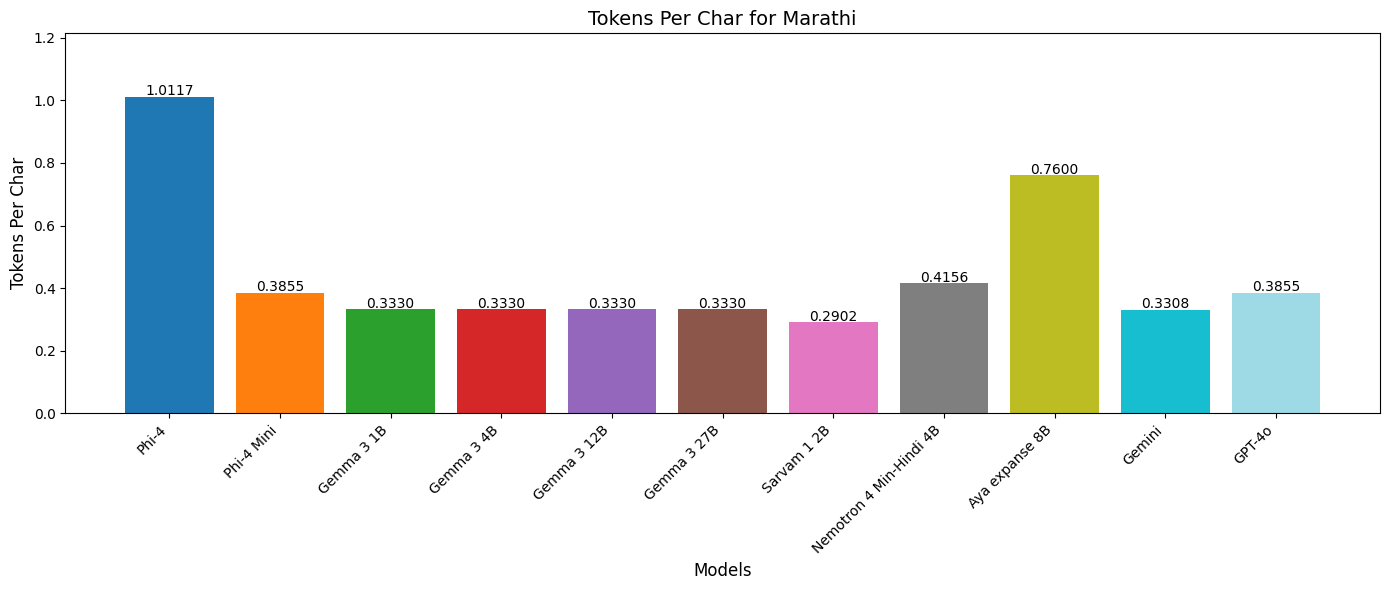

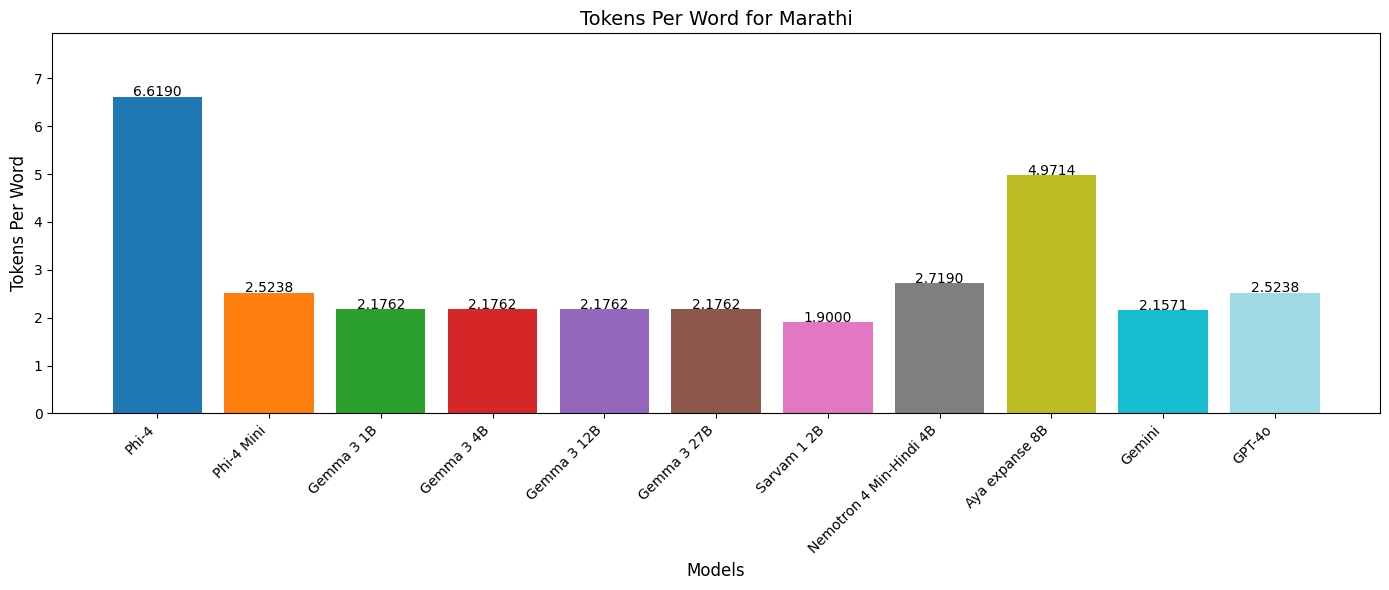

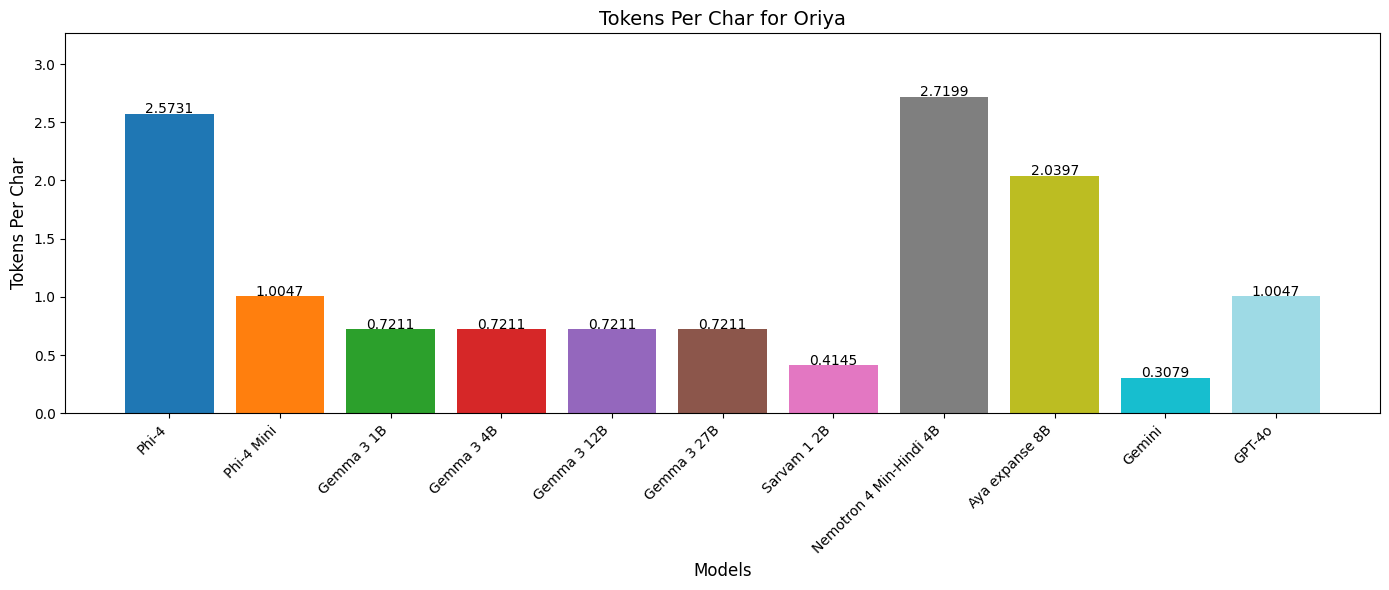

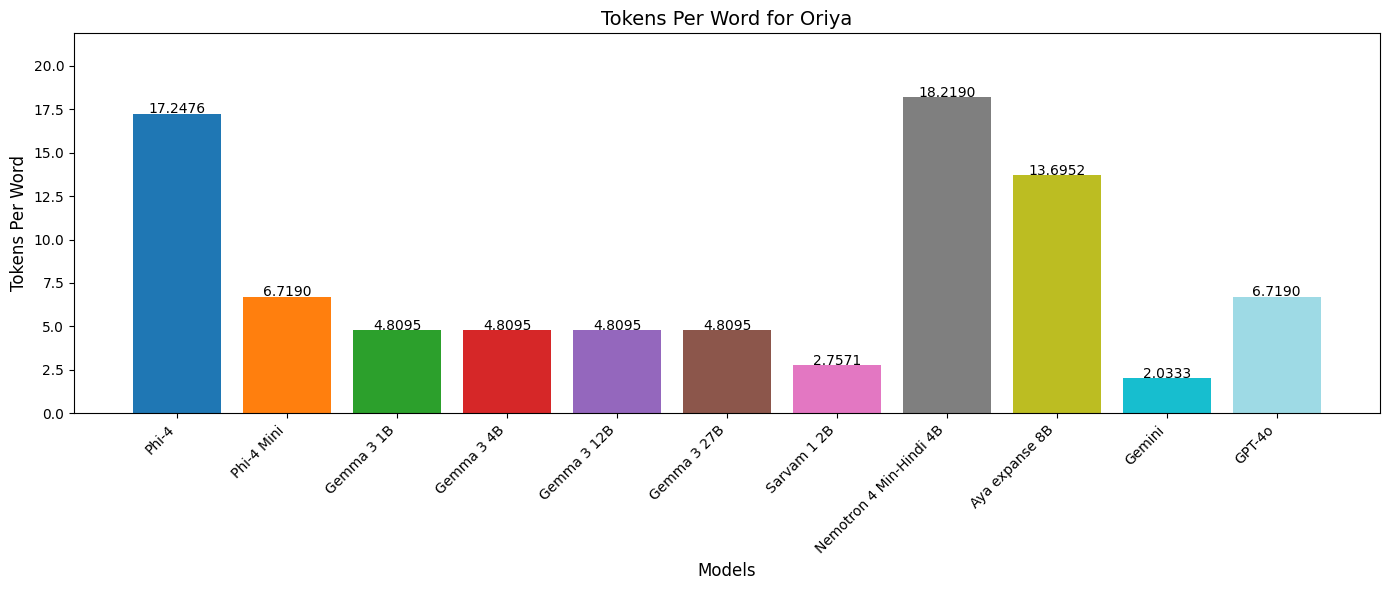

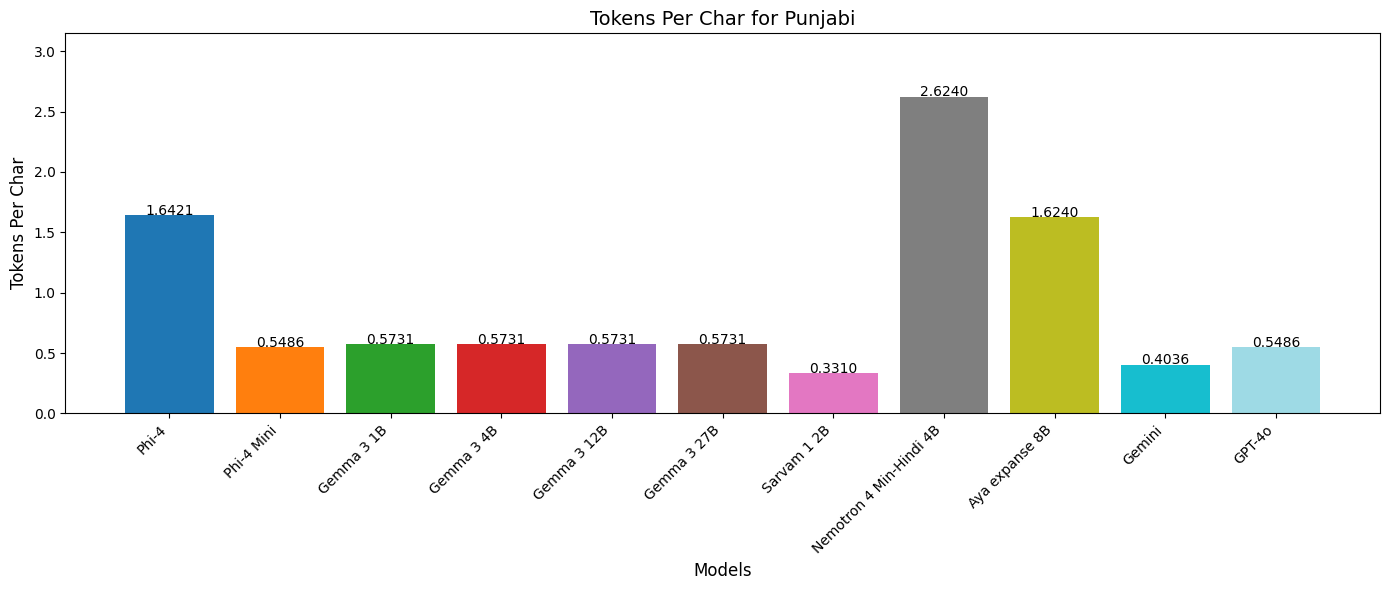

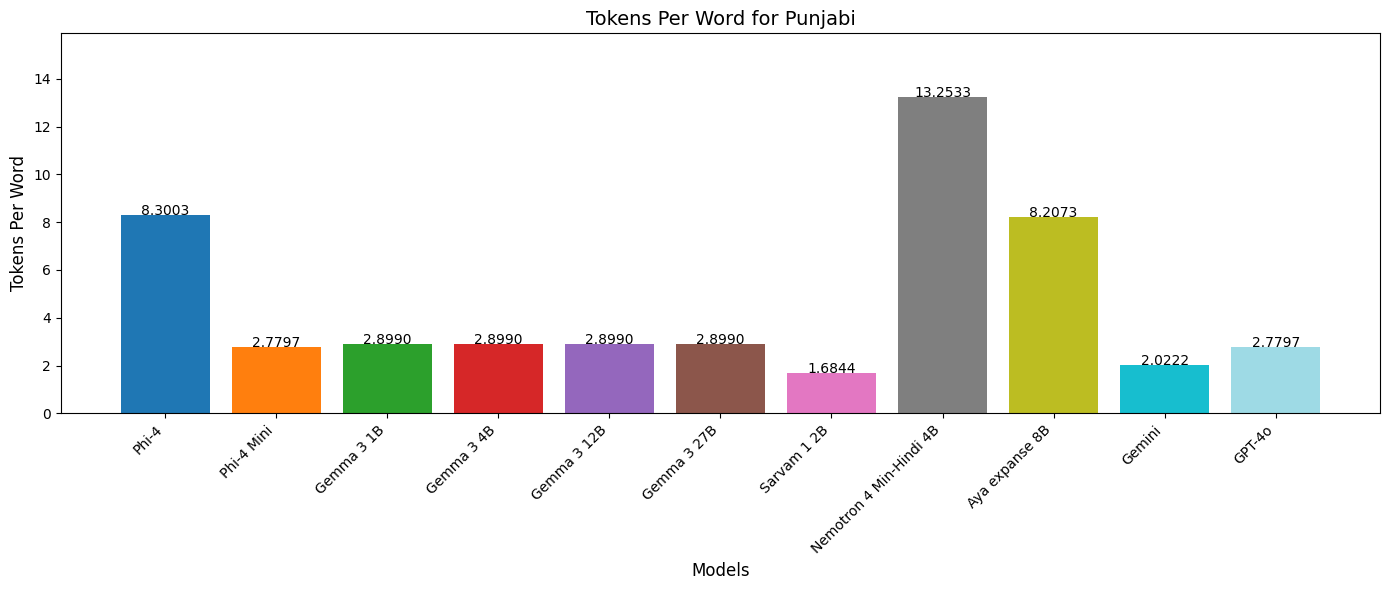

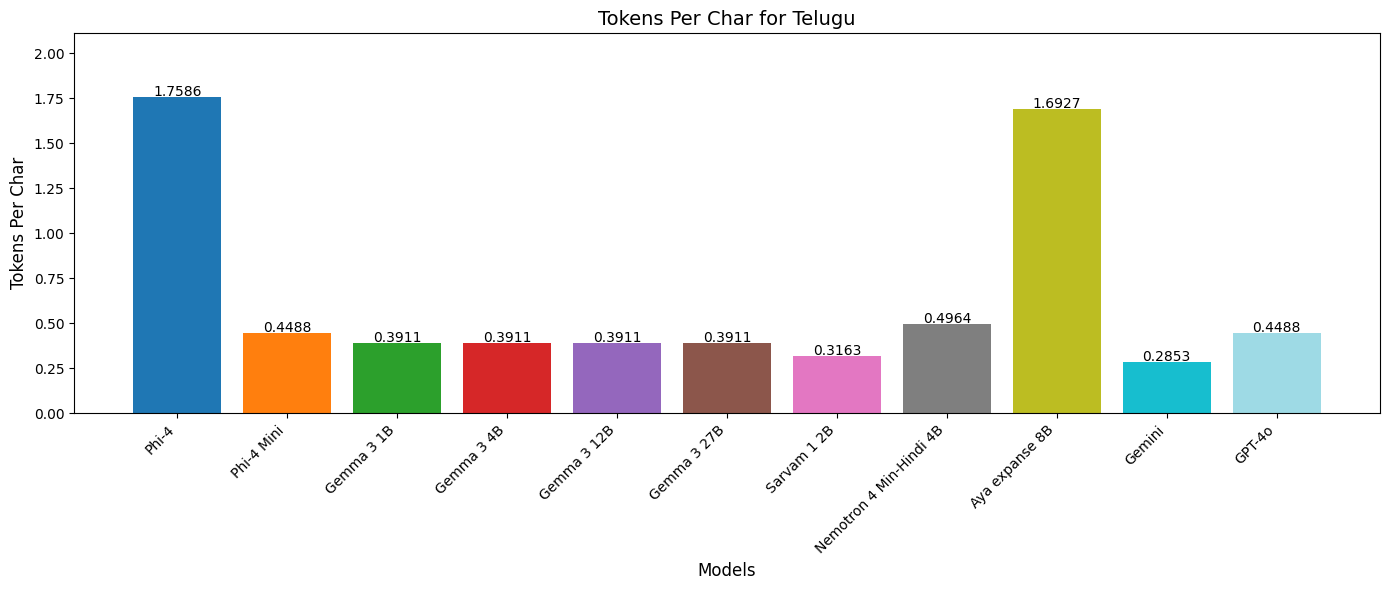

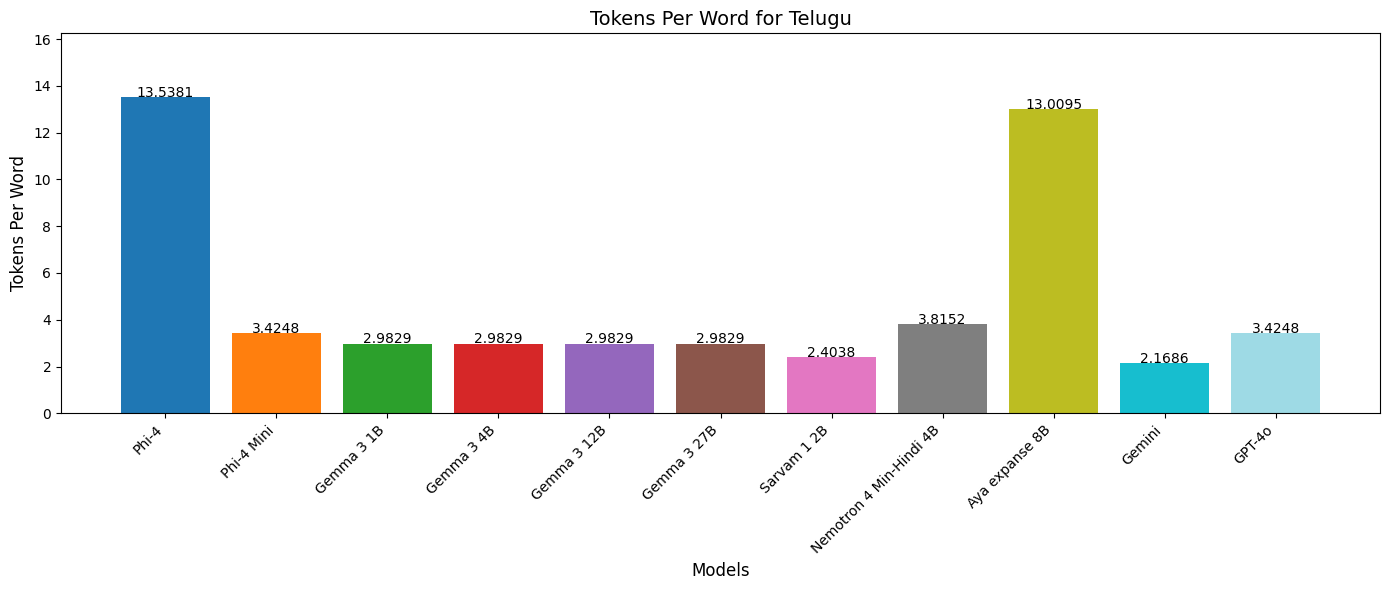

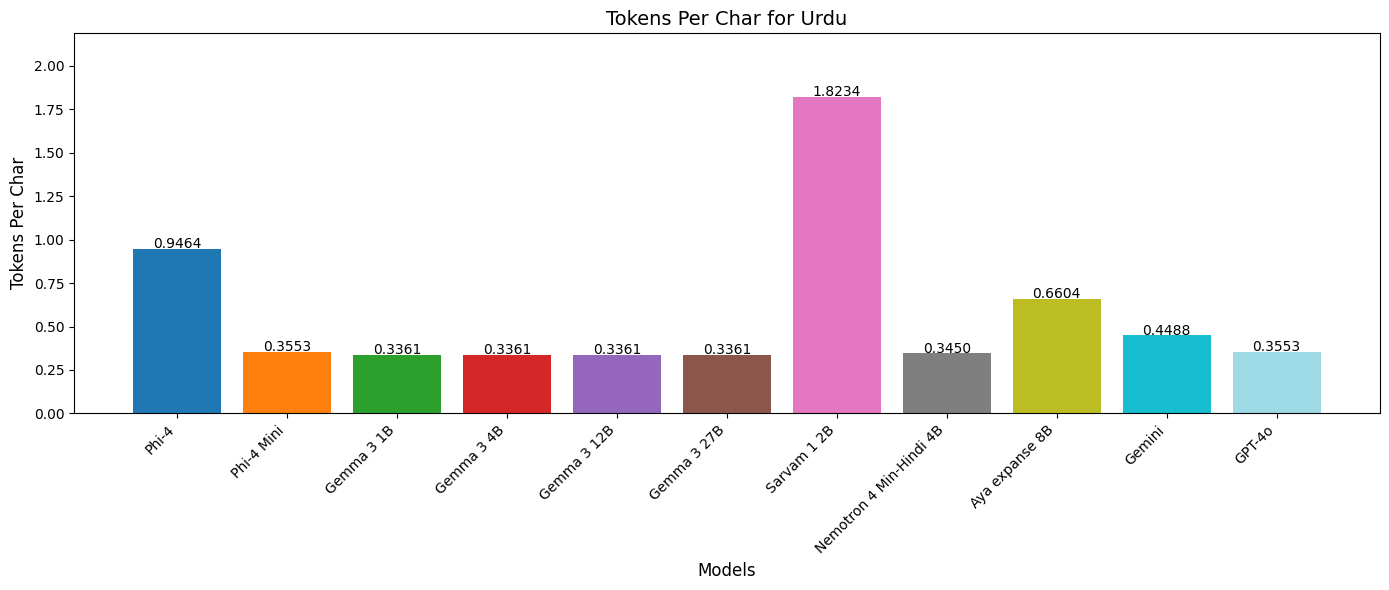

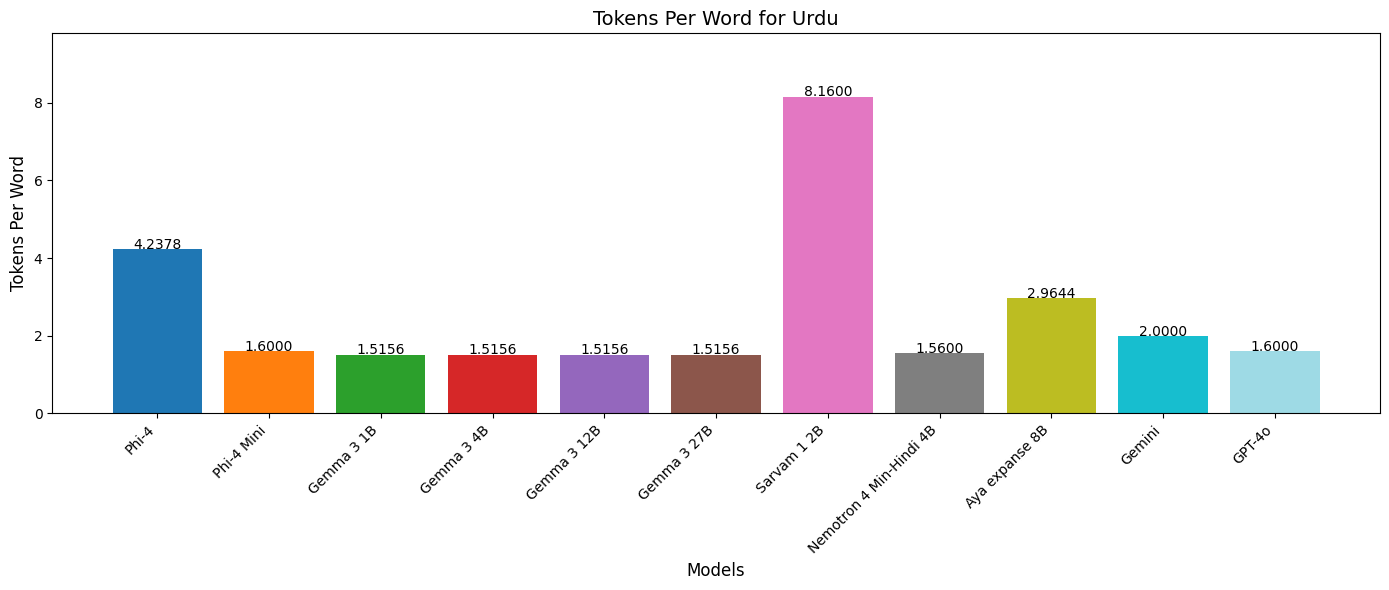

In [15]:
for lang in test_sentences.keys():
    plot_fertility_bar_graph(results, lang, metric_type="tokens_per_char")
    plot_fertility_bar_graph(results, lang, metric_type="tokens_per_word")

In [16]:
print("\n === Summary of Fertility Scores ===")
for model, metrics in results.items():
    print(f"\n{model}:")
    for lang in test_sentences.keys():
        tpc = metrics["tokens_per_char"][lang]
        tpw = metrics["tokens_per_word"][lang]
        print(f"  {lang}: {tpc:.4f} tokens/char, {tpw:.4f} tokens/word")


 === Summary of Fertility Scores ===

Phi-4:
  English: 0.2011 tokens/char, 1.2033 tokens/word
  Hindi: 1.0164 tokens/char, 5.0156 tokens/word
  Tamil: 1.3735 tokens/char, 11.3514 tokens/word
  Bengali: 1.2600 tokens/char, 8.1353 tokens/word
  Gujarati: 1.6561 tokens/char, 9.1226 tokens/word
  Kannada: 1.7609 tokens/char, 13.8821 tokens/word
  Malayalam: 1.6602 tokens/char, 13.7419 tokens/word
  Marathi: 1.0117 tokens/char, 6.6190 tokens/word
  Oriya: 2.5731 tokens/char, 17.2476 tokens/word
  Punjabi: 1.6421 tokens/char, 8.3003 tokens/word
  Telugu: 1.7586 tokens/char, 13.5381 tokens/word
  Urdu: 0.9464 tokens/char, 4.2378 tokens/word

Phi-4 Mini:
  English: 0.1939 tokens/char, 1.1461 tokens/word
  Hindi: 0.3545 tokens/char, 1.7467 tokens/word
  Tamil: 0.3751 tokens/char, 3.0819 tokens/word
  Bengali: 0.3775 tokens/char, 2.4234 tokens/word
  Gujarati: 0.4337 tokens/char, 2.3611 tokens/word
  Kannada: 0.4197 tokens/char, 3.2602 tokens/word
  Malayalam: 0.3832 tokens/char, 3.1657 tokens

In [17]:
def plot_average_fertility_across_languages(results, metric_type="tokens_per_char"):
    models = list(results.keys())
    avg_scores = []

    for model in models:
        lang_scores = results[model][metric_type]
        avg_score = np.mean(list(lang_scores.values()))
        avg_scores.append(avg_score)

    colors = plt.cm.tab20(np.linspace(0, 1, len(models)))

    plt.figure(figsize=(14, 6))
    bars = plt.bar(models, avg_scores, color=colors)
    plt.title(f'Average {metric_type.replace("_", " ").title()} Across All Languages', fontsize=14)
    plt.xlabel('Models', fontsize=12)
    plt.ylabel(f'{metric_type.replace("_", " ").title()}', fontsize=12)
    plt.ylim(0, max(avg_scores) * 1.2)
    plt.xticks(rotation=45, ha='right')
    for i, v in enumerate(avg_scores):
        plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=10)
    plt.tight_layout()
    plt.show()

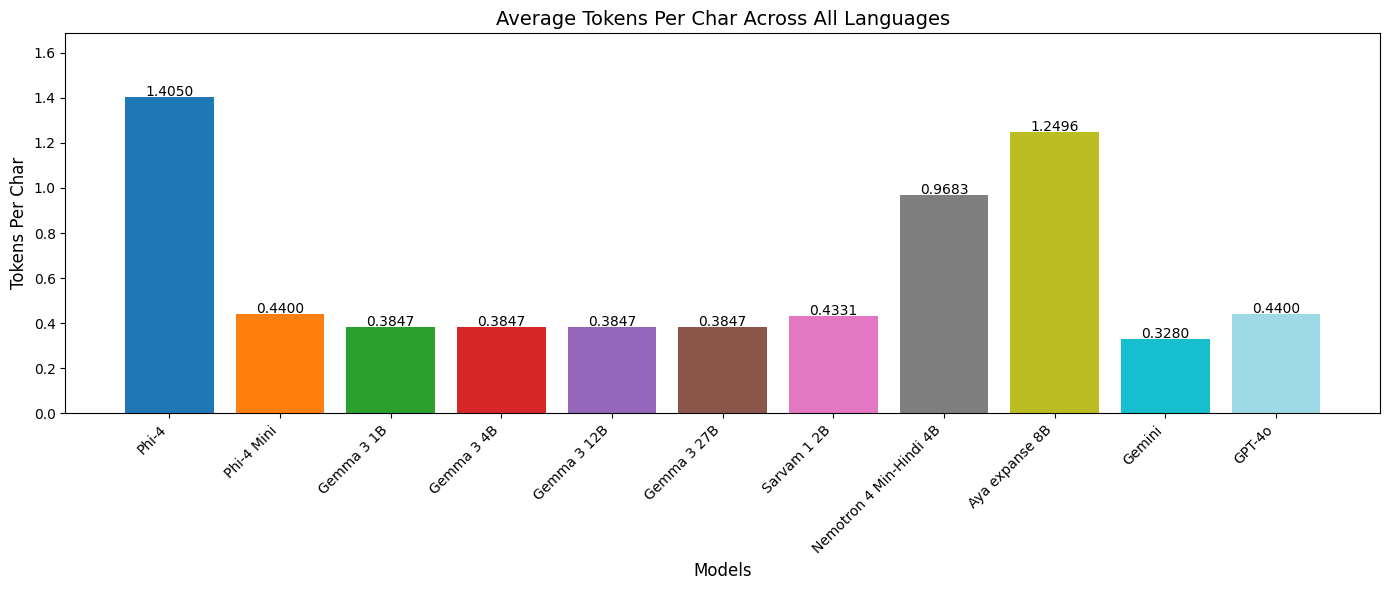

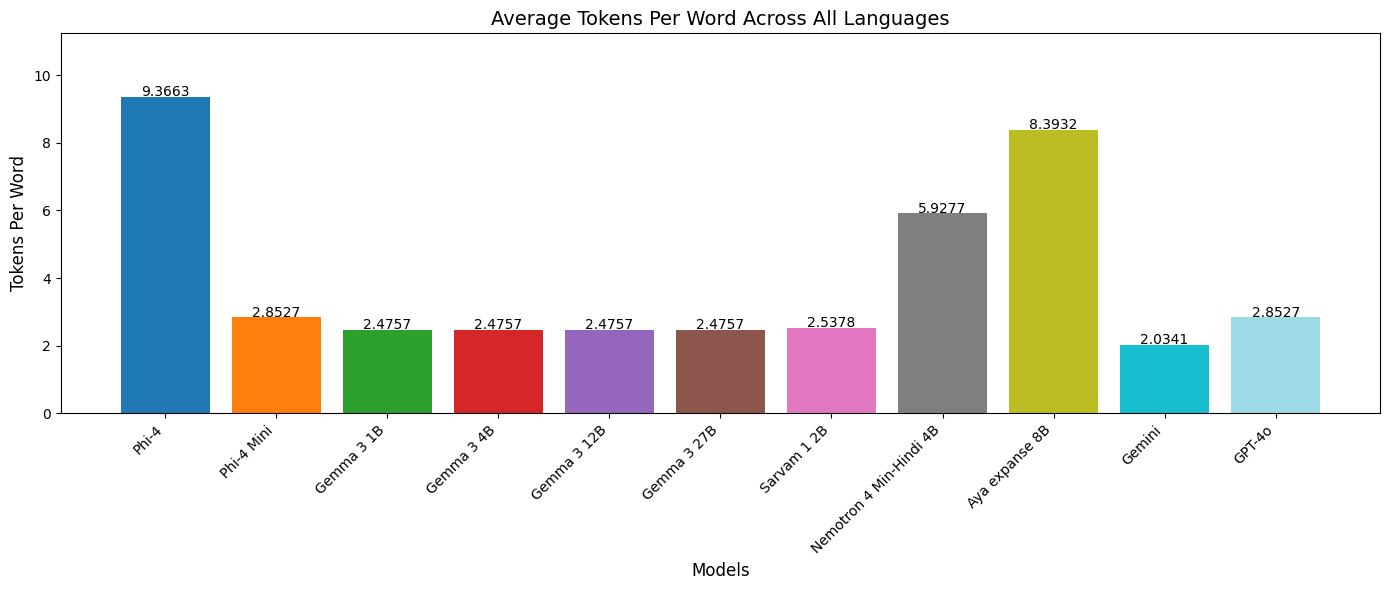

In [18]:
#  Average Across All Languages
plot_average_fertility_across_languages(results, metric_type="tokens_per_char")
plot_average_fertility_across_languages(results, metric_type="tokens_per_word")